# Fairy circles simulation
The following code demonstrates the formation of fairy circles and their underlying mechanisms. Within our modeling framework, we introduce the key concept of a "reduced resource-foraging range" to explain fairy circle formation. In simulations, this is implemented as kernel contraction of rn1. Specifically, we use shrub spot patterns as the initial spatial pattern, then forcibly reduce kn1 and introduce a substantial amount of grass. Additionally, we assume that shrubs are excluded by grasses and cannot regenerate, only experiencing mortality in simulation. By adding these rules to the base model, fairy circles emerge. Once fairy circles form, the system's density becomes stable, exhibiting metastability.

## Import libraries and define tools

In [2]:
import numpy as np
import pandas as pd
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
import matplotlib.colors as mcolors

# kernel generation tool
def create_circle_matrix(R, kernel_size):
    """
    创建圆形矩阵核 | Create a circular matrix kernel
    
    Parameters:
    -----------
    R : float
        圆的半径 | Radius of the circle
    kernel_size : int
        核的大小（必须是奇数）| Kernel size (must be odd)
    
    Returns:
    --------
    matrix : numpy.ndarray
        二值圆形矩阵 | Binary circular matrix
    """
    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be an odd number")
    
    matrix = np.zeros((kernel_size, kernel_size), dtype=int)
    center_x, center_y = kernel_size // 2, kernel_size // 2
    
    for i in range(kernel_size):
        for j in range(kernel_size):
            distance = np.sqrt((i - center_x) ** 2 + (j - center_y) ** 2)
            if distance <= R:
                matrix[i, j] = 1
    
    return matrix

## Creat initial spatial pattern

迭代步数 | Step: 0
迭代步数 | Step: 50
迭代步数 | Step: 100
迭代步数 | Step: 150
迭代步数 | Step: 200
迭代步数 | Step: 250
迭代步数 | Step: 300
迭代步数 | Step: 350
迭代步数 | Step: 400
迭代步数 | Step: 450


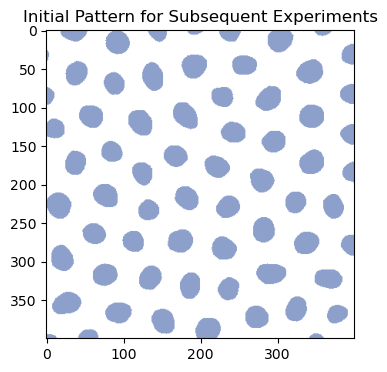

In [4]:
n = 600
s = 0.7  # 资源供给水平 | Resource supply level (0.7 灌木赢 | shrub wins, 0.8 草本赢 | grass wins)
np.random.seed(2234) 

# Kernal 物种1 (灌木 | shrub)
rn1 = 40  # 负效应半径 | Negative effect radius
rp1 = 4   # 正效应半径 | Positive effect radius
c1 = 5    # 资源消耗率 | Resource consumption rate

kn1 = create_circle_matrix(rn1, 81)
nn1 = np.count_nonzero(kn1)
kp1 = create_circle_matrix(rp1, 81)
np1 = np.count_nonzero(kp1)
kn1 = kn1 * (c1/s) / nn1 - kp1 * 0.05


# Kernal 物种2 (草本 | grass)
rn2 = 3   # 负效应半径 | Negative effect radius
rp2 = 1   # 正效应半径 | Positive effect radius
c2 = 3    # 资源消耗率 | Resource consumption rate

kn2 = create_circle_matrix(rn2, 7)
nn2 = np.count_nonzero(kn2)
kp2 = create_circle_matrix(rp2, 7)
np2 = np.count_nonzero(kp2)
kn2 = kn2 * (c2/s) / nn2 - kp2 * 0.01

# 模型初始化
p1 = 0.01  # 物种1初始密度 | Initial species 1 density
p2 = 0.00  # 物种2初始密度 | Initial species 2 density
matrix = np.random.choice([0, 1, 2], size=(n, n), p=[1-p1-p2, p1, p2])
matrix1 = matrix == 1  # 物种1分布 | Species 1 distribution
matrix2 = matrix == 2  # 物种2分布 | Species 2 distribution
density1 = []  # 物种1密度记录 | Species 1 density record
density2 = []  # 物种2密度记录 | Species 2 density record

# 开始迭代
steps = 500
for i in range(steps):
    density1.append(np.count_nonzero(matrix1) / n / n)
    density2.append(np.count_nonzero(matrix2) / n / n)
    
    # 扩散过程 | Dispersal process
    p1 = 0.5 * np.count_nonzero(matrix1) / n / n
    p2 = 0.5 * np.count_nonzero(matrix2) / n / n
    
    matrix_dispersal = np.random.choice([0, 1, 2], size=(n, n), 
                                       p=[(1-p1-p2), p1, p2]) * (1-np.logical_or(matrix1, matrix2))
    matrix_dispersal1 = matrix_dispersal == 1
    matrix_dispersal2 = matrix_dispersal == 2
    
    matrix_arena1 = np.logical_or(matrix_dispersal1, matrix1)
    matrix_arena2 = np.logical_or(matrix_dispersal2, matrix2)
    
    pad_width1 = ((kn1.shape[0] - 1) // 2, (kn1.shape[1] - 1) // 2)
    matrix_ext1 = np.pad(matrix_arena1, pad_width=pad_width1, mode='symmetric')
    netEffect1 = fftconvolve(matrix_ext1, kn1, mode='valid')
    
    pad_width2 = ((kn2.shape[0] - 1) // 2, (kn2.shape[1] - 1) // 2)
    matrix_ext2 = np.pad(matrix_arena2, pad_width=pad_width2, mode='symmetric')
    netEffect2 = fftconvolve(matrix_ext2, kn2, mode='valid')
    
    netEffect = netEffect1 + netEffect2
    
    # 根据资源进行下一轮更新 | Update based on influence field
    H1 = 1.0   # 物种1阈值 | Species 1 threshold
    H2 = 1.1   # 物种2阈值 | Species 2 threshold
    
    prob1 = matrix1 - (netEffect - H1) * 5
    prob2 = matrix2 - (netEffect - H2) * 0.5
    
    matrix1 = (np.random.rand(n, n) < prob1) * matrix_arena1
    matrix2 = (np.random.rand(n, n) < prob2) * matrix_arena2
    
    if i % 50 == 0:
        print(f"迭代步数 | Step: {i}")



# 保存初始状态用于后续实验 | Save initial state for后续 experiments
matback1 = matrix1[100:500, 200:600].copy()
plt.figure(figsize=(4, 4))
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', ['white', '#8DA0CB'])
plt.imshow(matback1, cmap=cmap)
plt.title('Initial Pattern for Subsequent Experiments')
plt.show()

## Experiment 1: Resource level s = 0.8

迭代步数 | Step: 0
迭代步数 | Step: 10
迭代步数 | Step: 20
迭代步数 | Step: 30
迭代步数 | Step: 40
迭代步数 | Step: 50
迭代步数 | Step: 60
迭代步数 | Step: 70
迭代步数 | Step: 80
迭代步数 | Step: 90
迭代步数 | Step: 100
迭代步数 | Step: 110
迭代步数 | Step: 120
迭代步数 | Step: 130
迭代步数 | Step: 140
迭代步数 | Step: 150
迭代步数 | Step: 160
迭代步数 | Step: 170
迭代步数 | Step: 180
迭代步数 | Step: 190
迭代步数 | Step: 200
迭代步数 | Step: 210
迭代步数 | Step: 220
迭代步数 | Step: 230
迭代步数 | Step: 240
迭代步数 | Step: 250
迭代步数 | Step: 260
迭代步数 | Step: 270
迭代步数 | Step: 280
迭代步数 | Step: 290
迭代步数 | Step: 300
迭代步数 | Step: 310
迭代步数 | Step: 320
迭代步数 | Step: 330
迭代步数 | Step: 340
迭代步数 | Step: 350
迭代步数 | Step: 360
迭代步数 | Step: 370
迭代步数 | Step: 380
迭代步数 | Step: 390
迭代步数 | Step: 400
迭代步数 | Step: 410
迭代步数 | Step: 420
迭代步数 | Step: 430
迭代步数 | Step: 440
迭代步数 | Step: 450
迭代步数 | Step: 460
迭代步数 | Step: 470
迭代步数 | Step: 480
迭代步数 | Step: 490


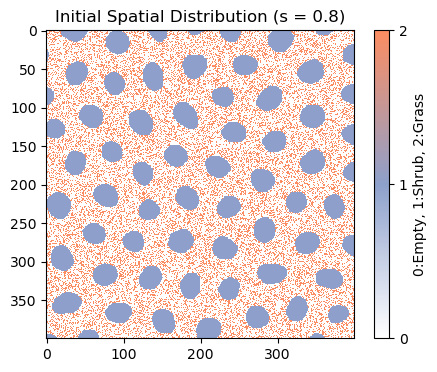

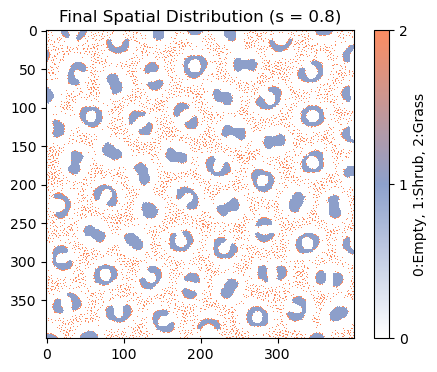

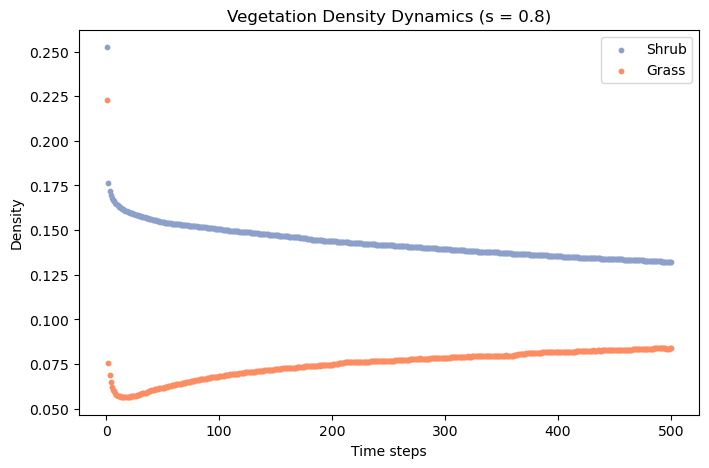

In [32]:
s = 0.8  # 资源供给水平 | Resource supply level

n = 400
matrix1 = matback1.copy()
# 在空地上随机初始化物种2 | Initialize species 2 randomly on empty cells
matrix2 = np.logical_and(np.logical_not(matback1), 
                        np.random.choice([0, 1], size=(n, n), p=[0.7, 0.3]))

plt.figure(figsize=(5, 4))
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', ['white', '#8DA0CB', '#FC8D62'])
plt.imshow(matrix1 + 2*matrix2, cmap=cmap, interpolation='nearest')
plt.title(f'Initial Spatial Distribution (s = {s})')
plt.colorbar(ticks=[0, 1, 2], label='0:Empty, 1:Shrub, 2:Grass')

# Kernal 物种1 (灌木 | shrub)
rn1 = 20  # 负效应半径 | Negative effect radius (kernel contraction)
rp1 = 4   # 正效应半径 | Positive effect radius
c1 = 5    # 资源消耗率 | Resource consumption rate

kn1 = create_circle_matrix(rn1, 81)
nn1 = np.count_nonzero(kn1)
kp1 = create_circle_matrix(rp1, 81)
np1 = np.count_nonzero(kp1)
kn1 = kn1 * (c1/s) / nn1 - kp1 * 0.05

# Kernal 物种2 (草本 | grass)
rn2 = 3   # 负效应半径 | Negative effect radius
rp2 = 1   # 正效应半径 | Positive effect radius
c2 = 3    # 资源消耗率 | Resource consumption rate

kn2 = create_circle_matrix(rn2, 7)
nn2 = np.count_nonzero(kn2)
kp2 = create_circle_matrix(rp2, 7)
np2 = np.count_nonzero(kp2)
kn2 = kn2 * (c2/s) / nn2 - kp2 * 0.01


density1 = []
density2 = []

# 开始迭代
steps = 500
for i in range(steps):
    density1.append(np.count_nonzero(matrix1) / n / n)
    density2.append(np.count_nonzero(matrix2) / n / n)
    
    # 扩散过程 | Dispersal process
    p1 = 0.5 * np.count_nonzero(matrix1) / n / n
    p2 = 0.5 * np.count_nonzero(matrix2) / n / n
    
    matrix_dispersal = np.random.choice([0, 1, 2], size=(n, n), 
                                       p=[(1-p1-p2), p1, p2]) * (1-np.logical_or(matrix1, matrix2))
    matrix_dispersal1 = matrix_dispersal == 1
    matrix_dispersal2 = matrix_dispersal == 2
    
    # 注意：物种1没有新生，只会死亡 | Note: Species 1 has no recruitment, only mortality
    matrix_arena1 = matrix1  
    matrix_arena2 = np.logical_or(matrix_dispersal2, matrix2)
    
    pad_width1 = ((kn1.shape[0] - 1) // 2, (kn1.shape[1] - 1) // 2)
    matrix_ext1 = np.pad(matrix_arena1, pad_width=pad_width1, mode='symmetric')
    netEffect1 = fftconvolve(matrix_ext1, kn1, mode='valid')
    
    pad_width2 = ((kn2.shape[0] - 1) // 2, (kn2.shape[1] - 1) // 2)
    matrix_ext2 = np.pad(matrix_arena2, pad_width=pad_width2, mode='symmetric')
    netEffect2 = fftconvolve(matrix_ext2, kn2, mode='valid')
    
    netEffect = netEffect1 + netEffect2
    
    # 根据资源进行下一轮更新 | Update based on influence field
    H1 = 1.0   # 物种1阈值 | Species 1 threshold
    H2 = 1.1   # 物种2阈值 | Species 2 threshold
    
    prob1 = matrix1 - (netEffect - H1) * 5
    prob2 = matrix2 - (netEffect - H2) * 0.5
    
    matrix1 = (np.random.rand(n, n) < prob1) * matrix_arena1
    matrix2 = (np.random.rand(n, n) < prob2) * matrix_arena2
    
    #if i % 10 == 0:
    #    print(f"迭代步数 | Step: {i}")

# 绘图检查
plt.figure(figsize=(5, 4))
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', ['white', '#8DA0CB', '#FC8D62'])
plt.imshow(matrix1 + 2*matrix2, cmap=cmap, interpolation='nearest')
plt.title(f'Final Spatial Distribution (s = {s})')
plt.colorbar(ticks=[0, 1, 2], label='0:Empty, 1:Shrub, 2:Grass')
plt.savefig("ring1.pdf", dpi=600, bbox_inches='tight')
plt.show()


plt.figure(figsize=(8, 5))
plt.scatter(list(range(1, steps+1)), density1, c="#8DA0CB", label='Shrub', s=10)
plt.scatter(list(range(1, steps+1)), density2, c="#FC8D62", label='Grass', s=10)
plt.xlabel('Time steps')
plt.ylabel('Density')
plt.legend()
plt.title(f'Vegetation Density Dynamics (s = {s})')
plt.show()

## Experiment 2: Resource level s = 0.9

迭代步数 | Step: 0
迭代步数 | Step: 50
迭代步数 | Step: 100
迭代步数 | Step: 150


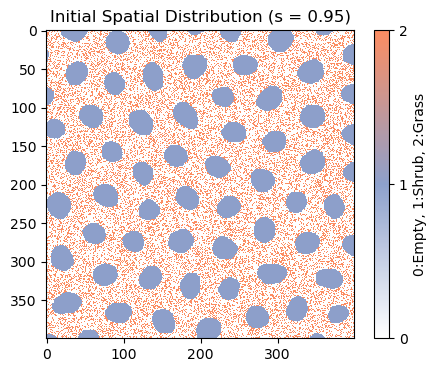

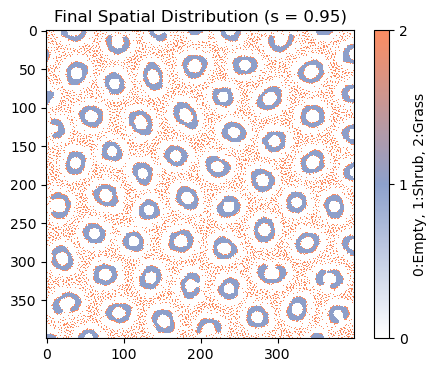

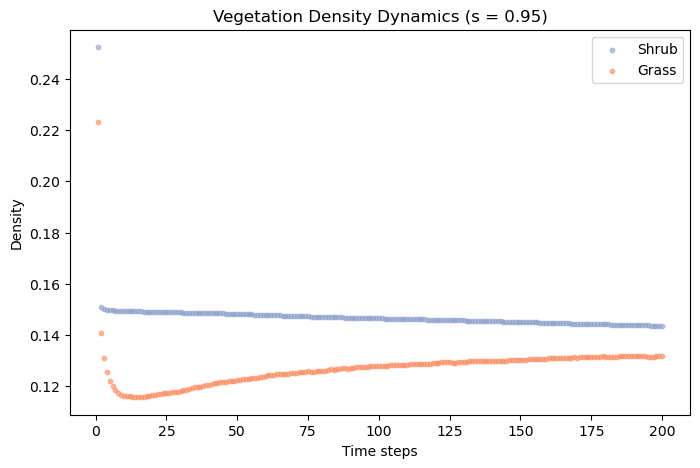

In [34]:
s = 0.9  # 资源供给水平 | Resource supply level


n = 400
matrix1 = matback1.copy()
# 在空地上随机初始化物种2 | Initialize species 2 randomly on empty cells
matrix2 = np.logical_and(np.logical_not(matback1), 
                        np.random.choice([0, 1], size=(n, n), p=[0.7, 0.3]))

plt.figure(figsize=(5, 4))
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', ['white', '#8DA0CB', '#FC8D62'])
plt.imshow(matrix1 + 2*matrix2, cmap=cmap, interpolation='nearest')
plt.title(f'Initial Spatial Distribution (s = {s})')
plt.colorbar(ticks=[0, 1, 2], label='0:Empty, 1:Shrub, 2:Grass')


# Kernal 物种1 (灌木 | shrub)
rn1 = 15  # 负效应半径 | Negative effect radius (kernel contraction)
rp1 = 4   # 正效应半径 | Positive effect radius
c1 = 5    # 资源消耗率 | Resource consumption rate

kn1 = create_circle_matrix(rn1, 81)
nn1 = np.count_nonzero(kn1)
kp1 = create_circle_matrix(rp1, 81)
np1 = np.count_nonzero(kp1)
kn1 = kn1 * (c1/s) / nn1 - kp1 * 0.05

# Kernal 物种2 (草本 | grass)
rn2 = 3   # 负效应半径 | Negative effect radius
rp2 = 1   # 正效应半径 | Positive effect radius
c2 = 3    # 资源消耗率 | Resource consumption rate

kn2 = create_circle_matrix(rn2, 7)
nn2 = np.count_nonzero(kn2)
kp2 = create_circle_matrix(rp2, 7)
np2 = np.count_nonzero(kp2)
kn2 = kn2 * (c2/s) / nn2 - kp2 * 0.01

density1 = []
density2 = []

# 开始迭代
steps = 200
for i in range(steps):
    density1.append(np.count_nonzero(matrix1) / n / n)
    density2.append(np.count_nonzero(matrix2) / n / n)
    
    # 扩散过程 | Dispersal process
    p1 = 0.5 * np.count_nonzero(matrix1) / n / n
    p2 = 0.5 * np.count_nonzero(matrix2) / n / n
    
    matrix_dispersal = np.random.choice([0, 1, 2], size=(n, n), 
                                       p=[(1-p1-p2), p1, p2]) * (1-np.logical_or(matrix1, matrix2))
    matrix_dispersal1 = matrix_dispersal == 1
    matrix_dispersal2 = matrix_dispersal == 2
    
    # 注意：物种1没有新生，只会死亡 | Note: Species 1 has no recruitment, only mortality
    matrix_arena1 = matrix1  
    matrix_arena2 = np.logical_or(matrix_dispersal2, matrix2)
    
    pad_width1 = ((kn1.shape[0] - 1) // 2, (kn1.shape[1] - 1) // 2)
    matrix_ext1 = np.pad(matrix_arena1, pad_width=pad_width1, mode='symmetric')
    netEffect1 = fftconvolve(matrix_ext1, kn1, mode='valid')
    
    pad_width2 = ((kn2.shape[0] - 1) // 2, (kn2.shape[1] - 1) // 2)
    matrix_ext2 = np.pad(matrix_arena2, pad_width=pad_width2, mode='symmetric')
    netEffect2 = fftconvolve(matrix_ext2, kn2, mode='valid')
    
    netEffect = netEffect1 + netEffect2
    
    # 根据资源进行下一轮更新 | Update based on influence field
    H1 = 1.0   # 物种1阈值 | Species 1 threshold
    H2 = 1.1   # 物种2阈值 | Species 2 threshold
    
    prob1 = matrix1 - (netEffect - H1) * 5
    prob2 = matrix2 - (netEffect - H2) * 0.5
    
    matrix1 = (np.random.rand(n, n) < prob1) * matrix_arena1
    matrix2 = (np.random.rand(n, n) < prob2) * matrix_arena2
    
    if i % 50 == 0:
        print(f"迭代步数 | Step: {i}")

# 绘图检查
plt.figure(figsize=(5, 4))
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', ['white', '#8DA0CB', '#FC8D62'])
plt.imshow(matrix1 + 2*matrix2, cmap=cmap, interpolation='nearest')
plt.title(f'Final Spatial Distribution (s = {s})')
plt.colorbar(ticks=[0, 1, 2], label='0:Empty, 1:Shrub, 2:Grass')
plt.show()


plt.figure(figsize=(8, 5))
plt.scatter(list(range(1, steps+1)), density1, c="#8DA0CB", label='Shrub', s=10, alpha=0.6)
plt.scatter(list(range(1, steps+1)), density2, c="#FC8D62", label='Grass', s=10, alpha=0.6)
plt.xlabel('Time steps')
plt.ylabel('Density')
plt.legend()
plt.title(f'Vegetation Density Dynamics (s = {s})')
plt.show()